<a href="https://colab.research.google.com/github/Sona-28/Sentiment-and-Sarcasm-Classification-COMM061/blob/main/NLP_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.2 Vocabulary Analysis**


In [ ]:
import pandas as pd

# File paths for each dataset split
splits = {
    "train": "data/train-00000-of-00001.parquet",
    "validation": "data/validation-00000-of-00001.parquet",
    "test": "data/test-00000-of-00001.parquet"
}

# Load each split into a pandas DataFrame
train_df = pd.read_parquet("hf://datasets/surrey-nlp/BESSTIE-CW-26/" + splits["train"])
val_df = pd.read_parquet("hf://datasets/surrey-nlp/BESSTIE-CW-26/" + splits["validation"])
test_df = pd.read_parquet("hf://datasets/surrey-nlp/BESSTIE-CW-26/" + splits["test"])

# Print the shape of each dataset split
print("Shape of Train split:", train_df.shape)
print("Shape of Validation split:", val_df.shape)
print("Shape of Test split:", test_df.shape)

# Display the first 5 rows of each split
display(train_df.head())
display(val_df.head())
display(test_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Shape of Train split: (3747, 5)
Shape of Validation split: (313, 5)
Shape of Test split: (2183, 5)


,text,variety,source,Sentiment,Sarcasm
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0


,text,variety,source,Sentiment,Sarcasm
0,"Had a great meal here. Friendly service, great...",en-AU,Google,1.0,0.0
1,Meh. Such a shame. Such a waste. Only single u...,en-AU,Google,0.0,0.0
2,How many sensors are broken? It is 28 degrees ...,en-IN,Reddit,0.0,1.0
3,Very economic ticket prices Balcony 1st class ...,en-IN,Google,1.0,0.0
4,Immigration is just the latest flashy issue by...,en-AU,Reddit,0.0,0.0


,text,variety,source,Sentiment,Sarcasm
0,"We are in the Yarra valley, we have a pair of ...",en-AU,Reddit,1.0,0.0
1,Been here twice and had a great time. Location...,en-AU,Google,1.0,0.0
2,"Was it a ""core"" or ""non-core"" commitment?\nThe...",en-AU,Reddit,0.0,1.0
3,Anyone proposing to run as a candidate for ele...,en-AU,Reddit,0.0,1.0
4,Yeah well out of this doctor and what he actua...,en-AU,Reddit,0.0,1.0


In [ ]:
# Print all column names in the training split
print("Columns in train_df: ",train_df.columns)

# Display the value counts of variety and source values
display(train_df["variety"].value_counts())
display(train_df["source"].value_counts())

Columns in train_df:  Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm'], dtype='object')


,count
variety,
en-IN,1399
en-UK,1203
en-AU,1145


,count
source,
Google,1874
Reddit,1873


In [ ]:
import spacy
from collections import Counter

# Create a blank English spaCy pipeline
nlp = spacy.blank("en")

def tokenize_series_spacy(text_series, batch_size=64):
  '''
  Tokenizes a series of text using spaCy.

  Preprocessing steps:
  1. Remove missing values and convert to string
  2. Convert to lowercase
  3. Tokenize using spaCy
  4. Filter out the unwanted tokens (spaces, punctuation, URLs, emails)

  Parameters:
  text_series (pd.Series): The series of text to be tokenized.
  batch_size (int): The number of texts to process in each batch.

  Returns:
  list: A list of lists, where each inner list contains the tokens for a text.
  '''
  texts = text_series.dropna().astype(str).str.lower().tolist()
  tokenized_docs = []

  for doc in nlp.pipe(texts, batch_size=batch_size):
      tokens = [
          token.text
          for token in doc
          if not token.is_space
          and not token.is_punct
          and not token.like_url
          and not token.like_email
      ]
      tokenized_docs.append(tokens)
  return tokenized_docs

def build_token_counter(tokenized_docs):
  '''
  Builds a frequency counter of all tokens across documents.

  Parameters:
  tokenized_docs (list): A list of lists, where each inner list contains the tokens for a text.

  Returns:
  Counter: A Counter object containing the frequency of each token.
  '''
  counter = Counter()
  for tokens in tokenized_docs:
    counter.update(tokens)
  return counter

In [ ]:
def jaccard_similarity(set_a, set_b):
  '''
  Calculates the Jaccard similarity between two sets.

  Steps:
  1. Calculate the intersection of the two sets.
  2. Calculate the union of the two sets.
  3. Calculate the Jaccard similarity as the ratio of the intersection to the union.

  Parameters:
  set_a (set): The first set.
  set_b (set): The second set.

  Returns:
  float: The Jaccard similarity between the two sets.
  '''
  intersection = len(set_a & set_b)
  union = len(set_a | set_b)
  return intersection / union if union != 0 else 0.0

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def tfidf_cosine_similarity_from_tokens(tokenized_docs_a, tokenized_docs_b, min_df=1):
  '''
  Calculated the cosine similarity between two sets of tokenized documents using TF-IDF.

  Steps:
  1. Convert the tokenized documents into a single string for each set.
  2. Convert text into TF-IDF vectors
  3. Compute the cosine similarity between the two vectors.

  Parameters:
  tokenized_docs_a (list): A list of lists, where each inner list contains the tokens for a text.
  tokenized_docs_b (list): A list of lists, where each inner list contains the tokens for a text.
  min_df (int): The minimum document frequency for a token to be considered.

  Returns:
  float: The cosine similarity between the two sets of tokenized documents.
  TfidfVectorizer: The TF-IDF vectorizer used to transform the tokenized documents.
  list: The feature names (tokens) used in the TF-IDF vectorizer.
  '''

  doc_a = " ".join([" ".join(tokens) for tokens in tokenized_docs_a])
  doc_b = " ".join([" ".join(tokens) for tokens in tokenized_docs_b])

  vectorizer = TfidfVectorizer(
      token_pattern=r"(?u)\b\w+\b",
      min_df=min_df
  )

  X = vectorizer.fit_transform([doc_a, doc_b])
  score = cosine_similarity(X[0], X[1])[0, 0]
  feature_names = vectorizer.get_feature_names_out()

  return score, vectorizer, feature_names

In [ ]:
def compare_varieties(df, variety_a, variety_b, source=None):
  '''
  Compare the vocabulary of two varieties, filtered by sources.

  Steps:
  1. Filter the DataFrame by optional source.
  2. Subset the DataFrame for each variety.
  3. Tokenize the text in each subset.
  4. Build frequency counters for each subset and extract unique vocabularies.
  5. Calculate Jaccard similarity and cosine similarity.
  6. Compute shared vocab, tokens unique to each variety.
  7. Return a dictionary containing the comparison results.

  Parameters:
  df (pd.DataFrame): The input DataFrame.
  variety_a (str): The first variety to compare.
  variety_b (str): The second variety to compare.
  source (str): Optional source to filter the DataFrame.

  Returns:
  dict: A dictionary containing vocabulary comparison metrics including sizes, shared tokens, Jaccard and cosine similarities.
  '''
  sub = df.copy()
  if source is not None:
      sub = sub[sub["source"] == source]

  a_df = sub[sub["variety"] == variety_a]
  b_df = sub[sub["variety"] == variety_b]

  a_tokens = tokenize_series_spacy(a_df["text"])
  b_tokens = tokenize_series_spacy(b_df["text"])

  a_counter = build_token_counter(a_tokens)
  b_counter = build_token_counter(b_tokens)

  a_vocab = set(a_counter.keys())
  b_vocab = set(b_counter.keys())

  jaccard = jaccard_similarity(a_vocab, b_vocab)
  cosine, _, _ = tfidf_cosine_similarity_from_tokens(a_tokens, b_tokens)

  return {
      "comparison": f"{variety_a} vs {variety_b}",
      "source": source if source is not None else "All",
      "vocab_a": len(a_vocab),
      "vocab_b": len(b_vocab),
      "shared_vocab": len(a_vocab & b_vocab),
      "a_only": len(a_vocab - b_vocab),
      "b_only": len(b_vocab - a_vocab),
      "jaccard_similarity": jaccard,
      "cosine_similarity": cosine
  }

# Use TRAIN ONLY for vocabulary analysis
analysis_df = train_df.copy()

# Vocabulary comparision results
all_rows = {
    "UK-IN All" : compare_varieties(analysis_df, "en-UK", "en-IN", source=None),
    "AU-IN All" : compare_varieties(analysis_df, "en-AU", "en-IN", source=None),
    "UK-AU All" : compare_varieties(analysis_df, "en-UK", "en-AU", source=None),
    "UK-IN Google" : compare_varieties(analysis_df, "en-UK", "en-IN", source="Google"),
    "AU-IN Google" : compare_varieties(analysis_df, "en-AU", "en-IN", source="Google"),
    "UK-AU Google" : compare_varieties(analysis_df, "en-UK", "en-AU", source="Google"),
    "UK-In Reddit" : compare_varieties(analysis_df, "en-UK", "en-IN", source="Reddit"),
    "AU-IN Reddit" : compare_varieties(analysis_df, "en-AU", "en-IN", source="Reddit"),
    "UK-AU Reddit" : compare_varieties(analysis_df, "en-UK", "en-AU", source="Reddit")
}

# Convert dictionary of results to a DataFrame with one row per comparison
results_df = pd.DataFrame(list(all_rows.values()), index=list(all_rows.keys()))

# Display the table rounded to 4 decimals
display(results_df.round(4))

,comparison,source,vocab_a,vocab_b,shared_vocab,a_only,b_only,jaccard_similarity,cosine_similarity
UK-IN All,en-UK vs en-IN,All,7469,7335,3353,4116,3982,0.2928,0.9497
AU-IN All,en-AU vs en-IN,All,8157,7335,3452,4705,3883,0.2867,0.9557
UK-AU All,en-UK vs en-AU,All,7469,8157,4018,3451,4139,0.3461,0.9877
UK-IN Google,en-UK vs en-IN,Google,5415,4131,2185,3230,1946,0.2968,0.9217
AU-IN Google,en-AU vs en-IN,Google,3478,4131,1732,1746,2399,0.2947,0.9253
UK-AU Google,en-UK vs en-AU,Google,5415,3478,2283,3132,1195,0.3454,0.9943
UK-In Reddit,en-UK vs en-IN,Reddit,3660,4670,1644,2016,3026,0.2459,0.9660
AU-IN Reddit,en-AU vs en-IN,Reddit,6486,4670,2216,4270,2454,0.2479,0.9628
UK-AU Reddit,en-UK vs en-AU,Reddit,3660,6486,2143,1517,4343,0.2678,0.9811


<Figure size 1200x600 with 0 Axes>

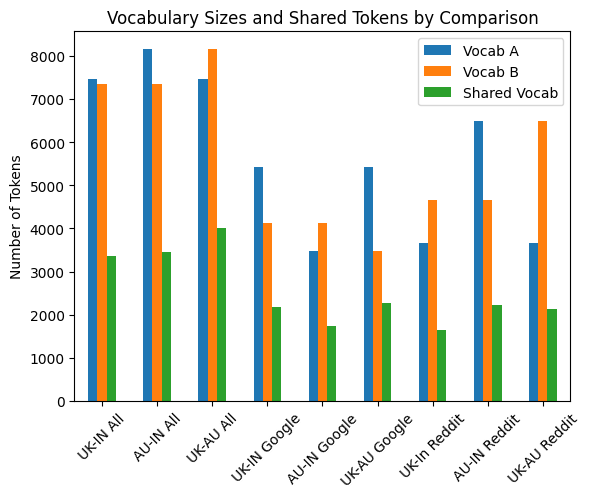

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Plot: Vocabulary Sizes and Shared Tokens
plt.figure(figsize=(12,6))
results_df[['vocab_a', 'vocab_b', 'shared_vocab']].plot(
    kind='bar'
)
plt.title('Vocabulary Sizes and Shared Tokens by Comparison')
plt.ylabel('Number of Tokens')
plt.xticks(range(len(results_df)), results_df.index, rotation=45)
plt.legend(['Vocab A', 'Vocab B', 'Shared Vocab'])
plt.show()


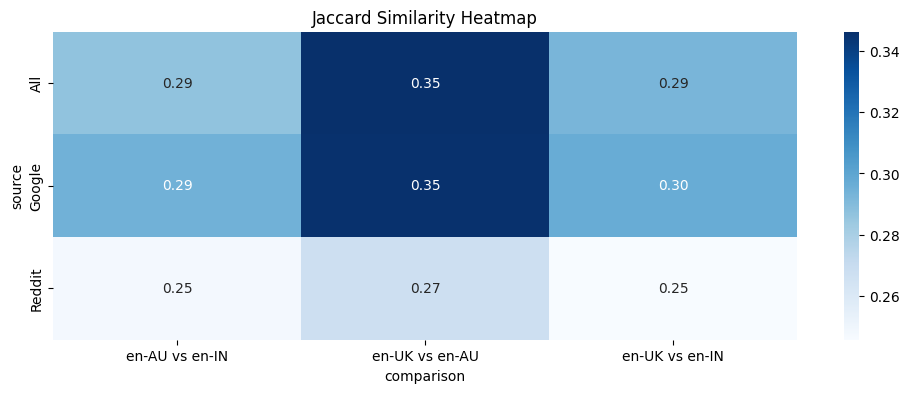

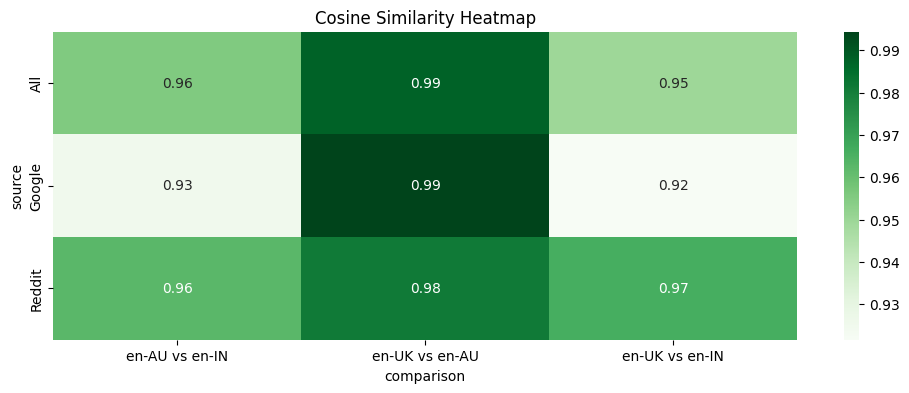

In [ ]:
# Heatmaps: Jaccard and Cosine Similarities
jaccard_pivot = results_df.pivot_table(index='source', columns='comparison', values='jaccard_similarity')
cosine_pivot = results_df.pivot_table(index='source', columns='comparison', values='cosine_similarity')

plt.figure(figsize=(12,4))
sns.heatmap(jaccard_pivot, annot=True, fmt=".2f", cmap='Blues')
plt.title("Jaccard Similarity Heatmap")
plt.show()

plt.figure(figsize=(12,4))
sns.heatmap(cosine_pivot, annot=True, fmt=".2f", cmap='Greens')
plt.title("Cosine Similarity Heatmap")
plt.show()
